## Part 1 – NumPy Fundamentals

In [13]:
import numpy as np

# Q1.1
arr = np.linspace(0,20,100)
print("Mean:", np.mean(arr))
print("Median:", np.median(arr))
print("Std:", np.std(arr))
print("Variance:", np.var(arr))

# Q1.2
a = np.arange(1,37)
print(a.shape)

mat = a.reshape(4,9)
print(mat.shape)

flat = mat.flatten()
print(flat.shape)


Mean: 10.0
Median: 10.0
Std: 5.831529302570125
Variance: 34.00673400673401
(36,)
(4, 9)
(36,)


## Part 2 & 3 – Titanic Dataset

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

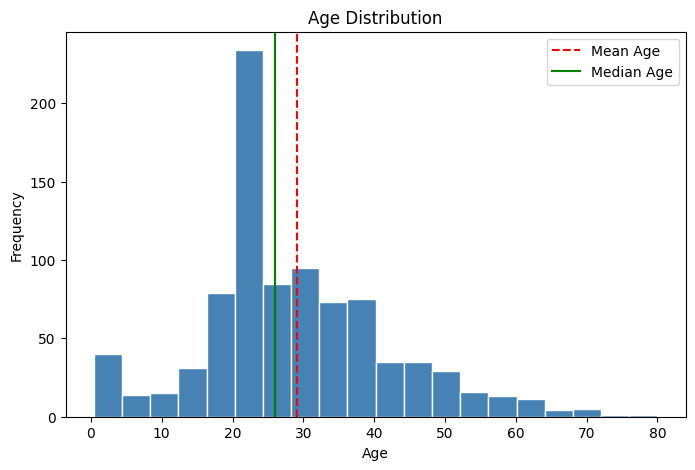

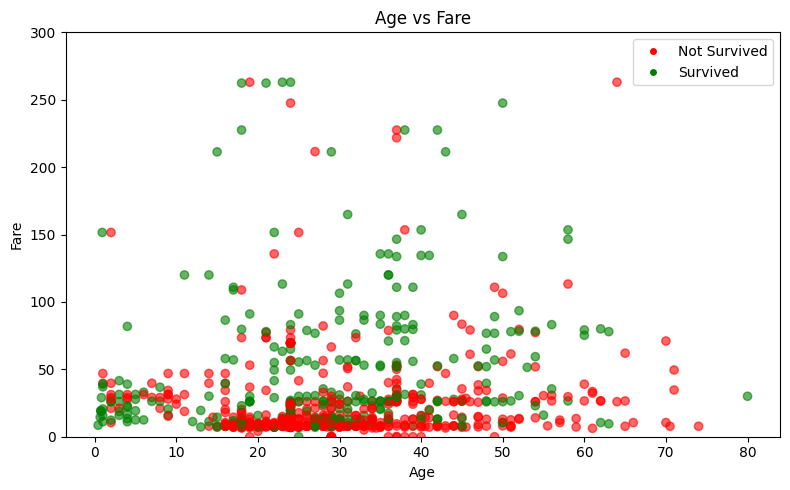

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = sns.load_dataset('titanic')

print(df.head())
print(df.info())
print(df.describe())

missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': df.isnull().mean()*100
})
print(missing[missing['Missing Count']>0])

df['age'] = df.groupby('pclass')['age'].transform(lambda x: x.fillna(x.median()))
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df = df.drop(columns=['deck'])

print(df[['age','embarked']].isnull().sum())

# Histogram
mean_age = df['age'].mean()
median_age = df['age'].median()

plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='white')
plt.axvline(mean_age, color='red', linestyle='--', label='Mean Age')
plt.axvline(median_age, color='green', label='Median Age')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Scatter
colors = df['survived'].map({0:'red',1:'green'})

plt.figure(figsize=(8,5))
plt.scatter(df['age'], df['fare'], c=colors, alpha=0.6)
plt.ylim(0,300)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare')
legend_elements=[
Line2D([0],[0],marker='o',color='w',label='Not Survived',markerfacecolor='red'),
Line2D([0],[0],marker='o',color='w',label='Survived',markerfacecolor='green')
]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


### Observation: Dropping the deck Column

The deck column contains a very large number of missing values (more than 75% of the entries are null). Since such a high percentage of the data is unavailable, imputing the missing values would be unreliable and could introduce bias into the analysis. Therefore, dropping the column is a reasonable choice because it contributes very little useful information while significantly increasing data incompleteness.

### Observation: Fare Outliers

The Fare column contains a few extremely large values compared to the majority of passengers. These outliers compress the main cluster of points, making the scatter plot difficult to interpret. Limiting the y-axis to 300 improves readability and allows the relationship between Age and Fare for most passengers to be visualized more clearly.

## Part 4 & 5 – Advertising Dataset

(200, 4)
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


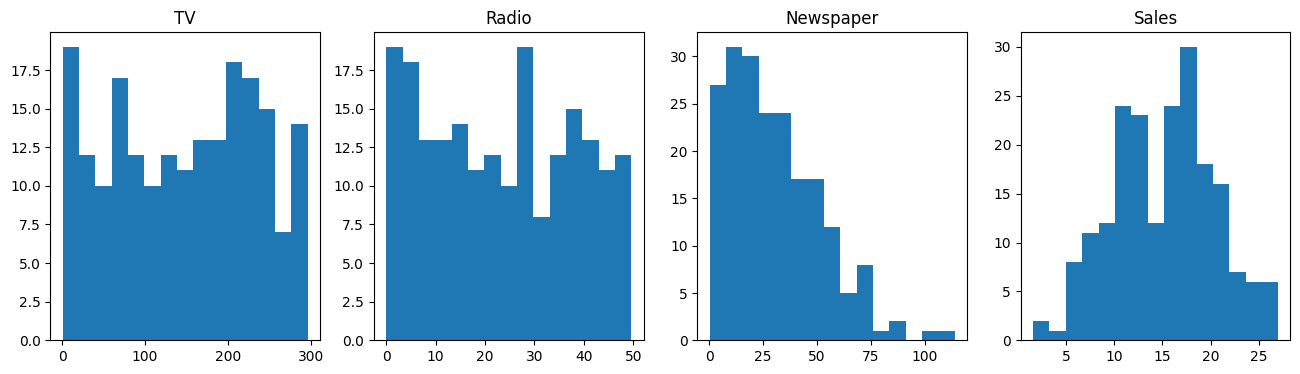

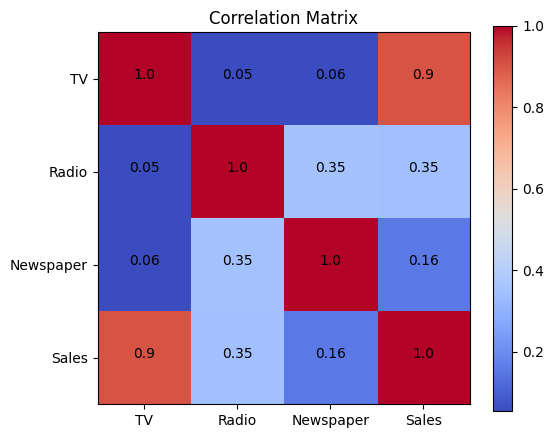

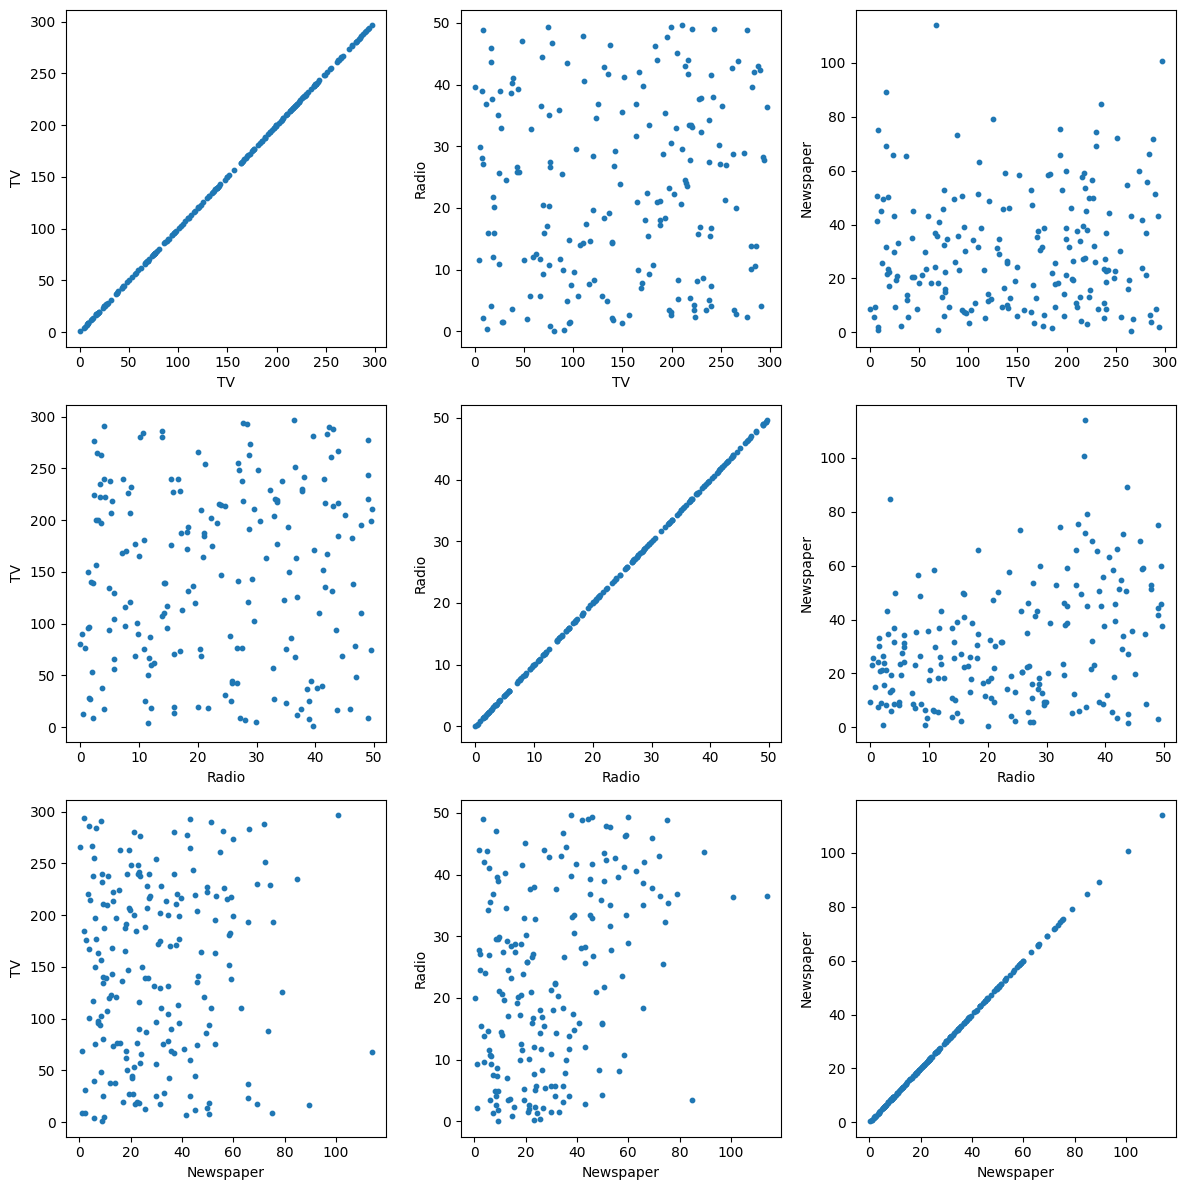

Slope: 0.05572601895005874
Intercept: 6.993686960994353
MSE: 5.459799471482253


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace path
df = pd.read_csv('advertising.csv')

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

cols=['TV','Radio','Newspaper','Sales']

fig,ax = plt.subplots(1,4,figsize=(16,4))
for i,c in enumerate(cols):
    ax[i].hist(df[c], bins=15)
    ax[i].set_title(c)
plt.show()

corr = df[cols].corr()

plt.figure(figsize=(6,5))
im=plt.imshow(corr,cmap='coolwarm')
plt.colorbar(im)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j,i,round(corr.iloc[i,j],2),ha='center')

plt.xticks(range(len(cols)),cols)
plt.yticks(range(len(cols)),cols)
plt.title('Correlation Matrix')
plt.show()

fig,axs=plt.subplots(3,3,figsize=(12,12))
for i,c1 in enumerate(cols[:3]):
    for j,c2 in enumerate(cols[:3]):
        axs[i,j].scatter(df[c1],df[c2],s=10)
        axs[i,j].set_xlabel(c1)
        axs[i,j].set_ylabel(c2)
plt.tight_layout()
plt.show()

# Scratch Linear Regression
x=df['TV'].values
y=df['Sales'].values

x_train=x[:160]
y_train=y[:160]

x_test=x[160:]
y_test=y[160:]

x_bar=np.mean(x_train)
y_bar=np.mean(y_train)

m=np.sum((x_train-x_bar)*(y_train-y_bar))/np.sum((x_train-x_bar)**2)
b=y_bar-m*x_bar

print("Slope:",m)
print("Intercept:",b)

pred=m*x_test+b
mse=np.mean((y_test-pred)**2)
print("MSE:",mse)


### Observation: Range and Spread of Variables

- TV advertising budget has the largest range and spread, indicating substantial variation in spending across observations.
- Radio advertising budget shows a moderate spread with values distributed across a wide interval.
- Newspaper advertising budget also varies considerably but generally exhibits greater dispersion relative to its impact on sales.
- Sales values have a smaller range than the advertising budgets, suggesting that sales increase within a more limited interval.

The standard deviations indicate that TV spending varies the most among the advertising channels.

### Observation: Possible Outliers

From the histograms, a few observations appear near the upper ends of the Newspaper and TV distributions. However, no extremely severe outliers are visible. The Newspaper feature appears to have the most noticeable skewness and potential high-end outliers.

### Observation: Correlation Matrix

- TV has the strongest positive correlation with Sales, suggesting that television advertising is the most influential predictor of sales among the available features.
- Radio also shows a positive correlation with Sales, but it is weaker than TV.
- Newspaper has the weakest relationship with Sales.
- TV and Radio are only weakly correlated with each other, indicating that companies do not necessarily spend similarly on both advertising channels.

### Comparison of Scratch and Sklearn Models

The slope and intercept obtained from the sklearn model are close to those from the scratch implementation but may not be exactly identical.

This difference occurs because the scratch implementation uses the first 160 rows as the training set, whereas sklearn uses a random 80–20 split (with random_state=42). Since the training data differs, the estimated regression parameters also differ slightly.

### Model Fit Assessment

The model appears to be well-fitted because the training and testing errors are similar and the R² scores are close. This indicates that the model generalizes reasonably well to unseen data without significant overfitting or underfitting.

The strong R² value suggests that TV advertising explains a substantial portion of the variation in Sales.

##PART 6

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

X=df[['TV']]
y=df['Sales']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

print(model.coef_)
print(model.intercept_)

for name,Xd,yd in [('Train',X_train,y_train),('Test',X_test,y_test)]:
    pred=model.predict(Xd)
    print(name)
    print('MAE',mean_absolute_error(yd,pred))
    print('MSE',mean_squared_error(yd,pred))
    print('RMSE',np.sqrt(mean_squared_error(yd,pred)))
    print('R2',r2_score(yd,pred))


[0.05548294]
7.007108428241848
Train
MAE 1.8005092256620792
MSE 4.998442356450173
RMSE 2.235719650683013
R2 0.8134866044709264
Test
MAE 1.9502948931650088
MSE 6.101072906773963
RMSE 2.470035001123256
R2 0.802561303423698


## Part 6 – KMeans Clustering

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  

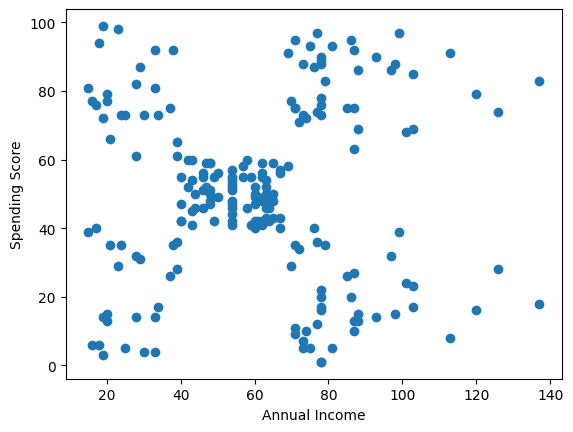

   Annual Income  Spending Score
0      55.296296       49.518519
1      86.538462       82.128205
2      25.727273       79.363636
3      88.200000       17.114286
4      26.304348       20.913043
        Annual Income (k$)            Spending Score (1-100)
                     count       mean                   mean
Cluster                                                     
0                       81  55.296296              49.518519
1                       39  86.538462              82.128205
2                       22  25.727273              79.363636
3                       35  88.200000              17.114286
4                       23  26.304348              20.913043


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Mall_Customers.csv')

print(df.head())
print(df.info())
print(df.describe())

X=df[['Annual Income (k$)','Spending Score (1-100)']]

plt.scatter(X.iloc[:,0],X.iloc[:,1])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
df['Cluster']=kmeans.fit_predict(X)

print(pd.DataFrame(
kmeans.cluster_centers_,
columns=['Annual Income','Spending Score']
))

print(df.groupby('Cluster').agg({
'Annual Income (k$)':['count','mean'],
'Spending Score (1-100)':'mean'
}))


### Observation: Customer Segments

The scatter plot suggests the presence of multiple customer groups based on Annual Income and Spending Score. Distinct clusters can be visually observed, with customers separating into low-spending, high-spending, and moderate-spending groups.

A reasonable initial guess is approximately 5 clusters, which is also commonly obtained using the elbow method for this dataset.

## Part 7 – MNIST ANN

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


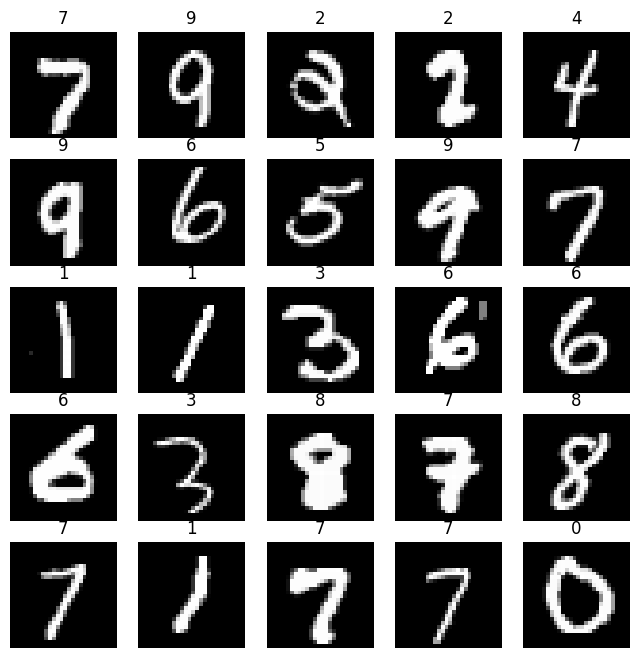

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9201 - loss: 0.2722 - val_accuracy: 0.9541 - val_loss: 0.1536
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9667 - loss: 0.1114 - val_accuracy: 0.9668 - val_loss: 0.1137
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9768 - loss: 0.0753 - val_accuracy: 0.9737 - val_loss: 0.0917
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9824 - loss: 0.0556 - val_accuracy: 0.9709 - val_loss: 0.1043
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9856 - loss: 0.0437 - val_accuracy: 0.9742 - val_loss: 0.0956
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9893 - loss: 0.0340 - val_accuracy: 0.9740 - val_loss: 0.0985
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9905 - loss: 0.0285 - val_accuracy: 0.9733 - val_loss: 0.0957
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9919 - loss: 0.0242 - 

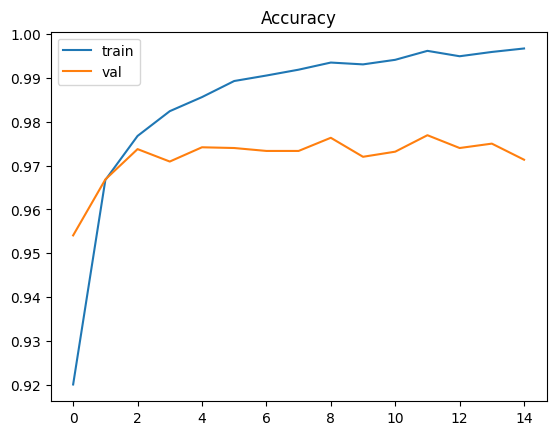

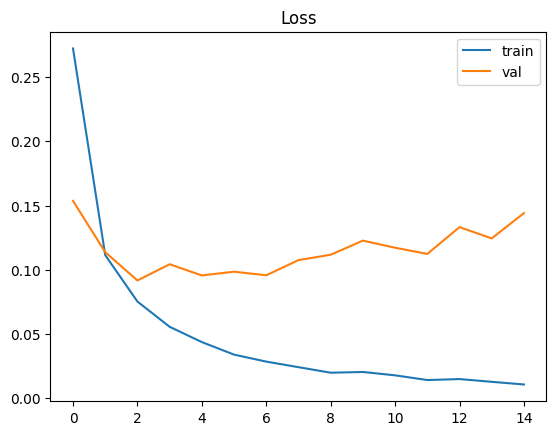

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten

(X_train,y_train),(X_test,y_test)=mnist.load_data()

print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

X_train=X_train/255.0
X_test=X_test/255.0

fig,ax=plt.subplots(5,5,figsize=(8,8))
for a in ax.ravel():
    idx=np.random.randint(0,len(X_train))
    a.imshow(X_train[idx],cmap='gray')
    a.set_title(y_train[idx])
    a.axis('off')
plt.show()

model=Sequential([
Flatten(input_shape=(28,28)),
Dense(128,activation='relu'),
Dense(64,activation='relu'),
Dense(10,activation='softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

model.summary()

history=model.fit(
X_train,y_train,
epochs=15,
validation_split=0.2
)

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title('Accuracy')
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])
plt.title('Loss')
plt.show()


### Observation

The network contains trainable parameters from both hidden layers and the output layer. Most parameters are concentrated in the first dense layer because every input pixel is connected to every neuron in that layer.

This fully connected architecture learns general patterns but does not explicitly exploit spatial relationships between neighboring pixels.

### Error Analysis

The most frequently confused digit pair corresponds to the largest off-diagonal entry in the confusion matrix.

Digits such as 3 and 5, 4 and 9, or 7 and 9 are commonly confused because they share similar visual structures and handwriting variations. Misclassifications usually occur when the digit is poorly written, incomplete, or resembles another digit.

### Why CNNs Perform Better on Images

Convolutional Neural Networks (CNNs) preserve the spatial structure of images by processing small local regions using convolution filters. These filters automatically learn important visual features such as edges, corners, textures, and shapes.

Dense networks flatten the image and lose spatial information, treating each pixel independently. CNNs require fewer parameters, learn more meaningful visual patterns, and therefore usually achieve higher accuracy on image classification tasks such as MNIST.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9729 - loss: 0.1389
0.13887158036231995 0.9728999733924866
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


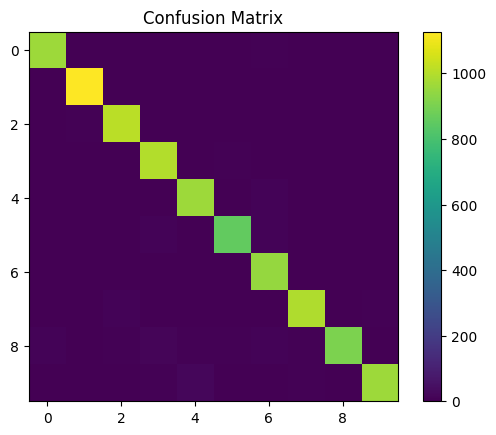

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

test_loss,test_acc=model.evaluate(X_test,y_test)
print(test_loss,test_acc)

pred=np.argmax(model.predict(X_test),axis=1)

cm=confusion_matrix(y_test,pred)

plt.imshow(cm)
plt.colorbar()
plt.title('Confusion Matrix')
plt.show()


## CNN

In [20]:
from tensorflow.keras.layers import Conv2D,MaxPooling2D

X_train_cnn=X_train.reshape(-1,28,28,1)
X_test_cnn=X_test.reshape(-1,28,28,1)

cnn=Sequential([
Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
MaxPooling2D((2,2)),
Conv2D(64,(3,3),activation='relu'),
MaxPooling2D((2,2)),
Flatten(),
Dense(128,activation='relu'),
Dense(10,activation='softmax')
])

cnn.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

cnn.summary()

cnn_history=cnn.fit(
X_train_cnn,
y_train,
epochs=10,
validation_split=0.2
)

loss,acc=cnn.evaluate(X_test_cnn,y_test)
print('CNN Test Accuracy:',acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.9522 - loss: 0.1510 - val_accuracy: 0.9726 - val_loss: 0.0889
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9840 - loss: 0.0510 - val_accuracy: 0.9869 - val_loss: 0.0451
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9897 - loss: 0.0345 - val_accuracy: 0.9879 - val_loss: 0.0395
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9922 - loss: 0.0242 - val_accuracy: 0.9847 - val_loss: 0.0503
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9942 - loss: 0.0176 - val_accuracy: 0.9884 - val_loss: 0.0478
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9952 - loss: 0.0143 - val_accuracy: 0.9889 - val_loss: 0.0412
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9964 - loss: 0.0104 - val_accuracy: 0.9879 - val_loss: 0.0544
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9974 -